# Layer 1; 32; 3x3; AvgPool

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


## Import Libraries

In [1]:
import os

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
tf.test.is_built_with_cuda()

2026-05-12 15:26:12.823473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778599573.241219      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778599573.355945      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778599574.476856      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778599574.476900      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778599574.476903      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


True

## Config

In [2]:
TRAIN_DIR  = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'
VAL_DIR    = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'
TEST_DIR   = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred'
MODEL_DIR = '/kaggle/working/models/cnn'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE    = (150, 150)
BATCH_SIZE  = 64
EPOCHS      = 10
NUM_CLASSES = 6
LR          = 1e-4
VAL_SPLIT   = 0.2

## Import Dataset

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

normalization = keras.layers.Rescaling(1.0 / 255.0)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
)
class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

train_ds = (
    train_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

train_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
val_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
test_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=1, label_mode="int", shuffle=False
))

print("Kelas      :", {name: i for i, name in enumerate(class_names)})
print(f"Train      : {train_count} gambar")
print(f"Validation : {val_count} gambar")
print(f"Test       : {test_count} gambar")

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1778599622.918438      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778599622.924446      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Kelas      : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Train      : 11228 gambar
Validation : 2806 gambar
Test       : 3000 gambar


## CNN Model Baseline Architecture

In [30]:
MODEL_NAME = 'Layer-2-32-64-3x3-avgpool'
model = keras.Sequential([
    keras.layers.Input(shape=IMG_SIZE + (3,), name='input'),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='valid', name='conv2s_1'),
    keras.layers.AveragePooling2D((2, 2), name='avgpool_1'),
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv2s_2'),
    keras.layers.AveragePooling2D((2, 2), name='avgpool_2'),
    keras.layers.Flatten(name='flatten'),
    keras.layers.Dense(128, activation='relu', name='dense_1'),
    keras.layers.Dense(6, activation='softmax', name='output'),
], name=MODEL_NAME)
model.summary()

Model: "Layer-2-32-64-3x3-avgpool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2s_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool_1 (AveragePooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2s_2 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool_2 (AveragePooling2D)    │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,637,126 (40.58 MB)

 Trainable params: 10,637,126 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation and Training

In [31]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callback = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'/kaggle/working/models/cnn/{MODEL_NAME}.h5',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callback,
    verbose=1
)

Epoch 1/10
174/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4782 - loss: 1.3245
Epoch 1: val_loss improved from inf to 0.79879, saving model to /kaggle/working/models/cnn/Layer-2-32-64-3x3-avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.4798 - loss: 1.3212 - val_accuracy: 0.7056 - val_loss: 0.7988
Epoch 2/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6774 - loss: 0.8643
Epoch 2: val_loss improved from 0.79879 to 0.78047, saving model to /kaggle/working/models/cnn/Layer-2-32-64-3x3-avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6774 - loss: 0.8644 - val_accuracy: 0.7170 - val_loss: 0.7805
Epoch 3/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7150 - loss: 0.7848
Epoch 3: val_loss improved from 0.78047 to 0.58089, saving model to /kaggle/working/models/cnn/Layer-2-32-64-3x3-avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7150 - loss: 0.7847 - val_accuracy: 0.8058 - val_loss: 0.5809
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7530 - loss: 0.7076
Epoch 4: val_loss improved from 0.58089 to 0.42670, saving model to /kaggle/working/models/cnn/Layer-2-32-64-3x3-avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7530 - loss: 0.7076 - val_accuracy: 0.8678 - val_loss: 0.4267
Epoch 5/10
174/176 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7839 - loss: 0.6281
Epoch 5: val_loss did not improve from 0.42670
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7838 - loss: 0.6282 - val_accuracy: 0.8443 - val_loss: 0.4688
Epoch 6/10
174/176 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8000 - loss: 0.5757
Epoch 6: val_loss did not improve from 0.42670
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8000 - loss: 0.5757 - val_accuracy: 0.8211 - val_loss: 0.5246
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8173 - loss: 0.5366
Epoch 7: val_loss improved from 0.42670 to 0.38285, saving model to /kaggle/working/models/cnn/Layer-2-32-64-3x3-avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8173 - loss: 0.5366 - val_accuracy: 0.8813 - val_loss: 0.3828
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8338 - loss: 0.4845
Epoch 8: val_loss did not improve from 0.38285
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8338 - loss: 0.4846 - val_accuracy: 0.8325 - val_loss: 0.4793
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8484 - loss: 0.4500
Epoch 9: val_loss improved from 0.38285 to 0.30594, saving model to /kaggle/working/models/cnn/Layer-2-32-64-3x3-avgpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8484 - loss: 0.4500 - val_accuracy: 0.9063 - val_loss: 0.3059
Epoch 10/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8684 - loss: 0.4134
Epoch 10: val_loss did not improve from 0.30594
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8684 - loss: 0.4134 - val_accuracy: 0.8835 - val_loss: 0.3765
Restoring model weights from the end of the best epoch: 9.


## Evaluation

In [32]:
y_pred_proba = model.predict(test_ds)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds])

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step
Macro F1 Score: 0.7684


## Plot

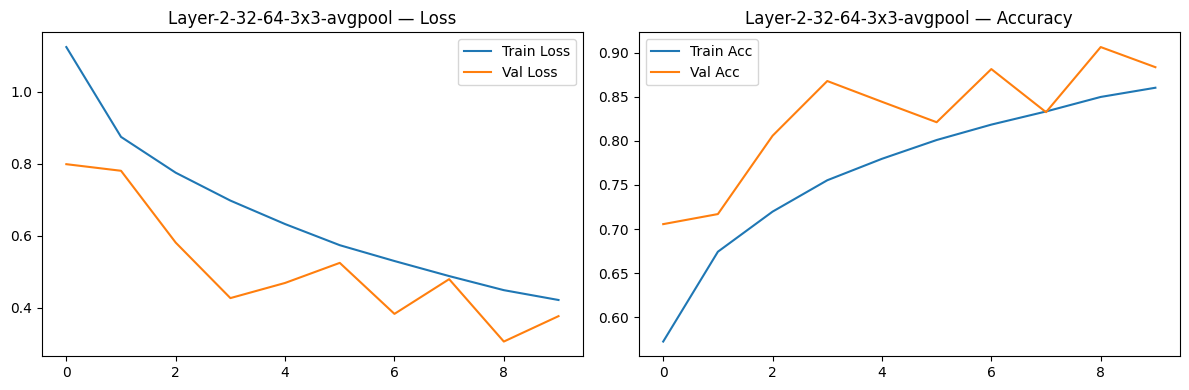

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],         label='Train Loss')
ax1.plot(history.history['val_loss'],     label='Val Loss')
ax1.set_title(f'{MODEL_NAME} — Loss'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title(f'{MODEL_NAME} — Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, f'{MODEL_NAME}_curve.png'), dpi=100)
plt.show()